# Laboratorio 4 — Cuaderno 4: análisis espacial

**Ejercicio 5.** Dónde se concentra la cianobacteria dentro de cada lago, si hay zonas que se
repiten y cómo cambia el reparto entre fechas.

El promedio de un lago esconde mucho. Un lago puede tener un promedio tranquilo y aun así tener
una bahía con una floración densa. Este cuaderno mira el interior del espejo de agua.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import warnings

import branca.colormap as cm
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from folium.plugins import Fullscreen

from src import config, datos, graficos
from src import indices as ix

resumen = datos.tabla_resumen()
print(f"{len(resumen)} escenas cargadas")

22 escenas cargadas


## 5.1 Distribución de la cianobacteria dentro de cada lago

### Mapa interactivo

Cada fecha es una capa que se puede prender y apagar con el control de la esquina superior
derecha. El fondo es un mapa satelital, así que se puede ubicar cada mancha respecto a los
pueblos, los ríos que entran y la forma de la orilla.

Las imágenes vienen en la proyección UTM del satélite y el mapa de folium trabaja en latitud y
longitud, así que hay que reproyectarlas antes de superponerlas; si no, quedarían corridas
respecto al fondo.

Guardado en data/figuras/mapa_Atitlan.html



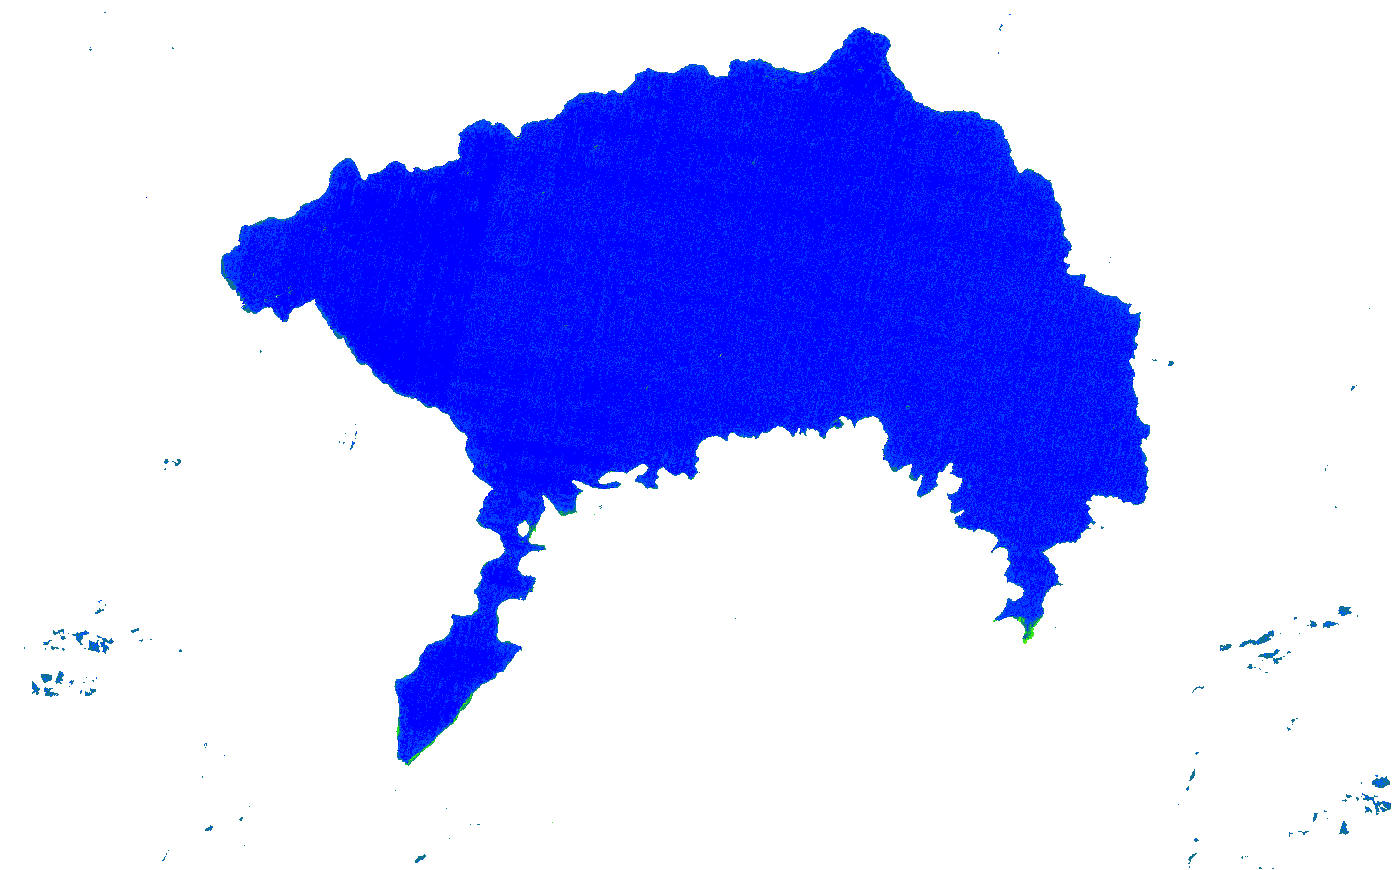
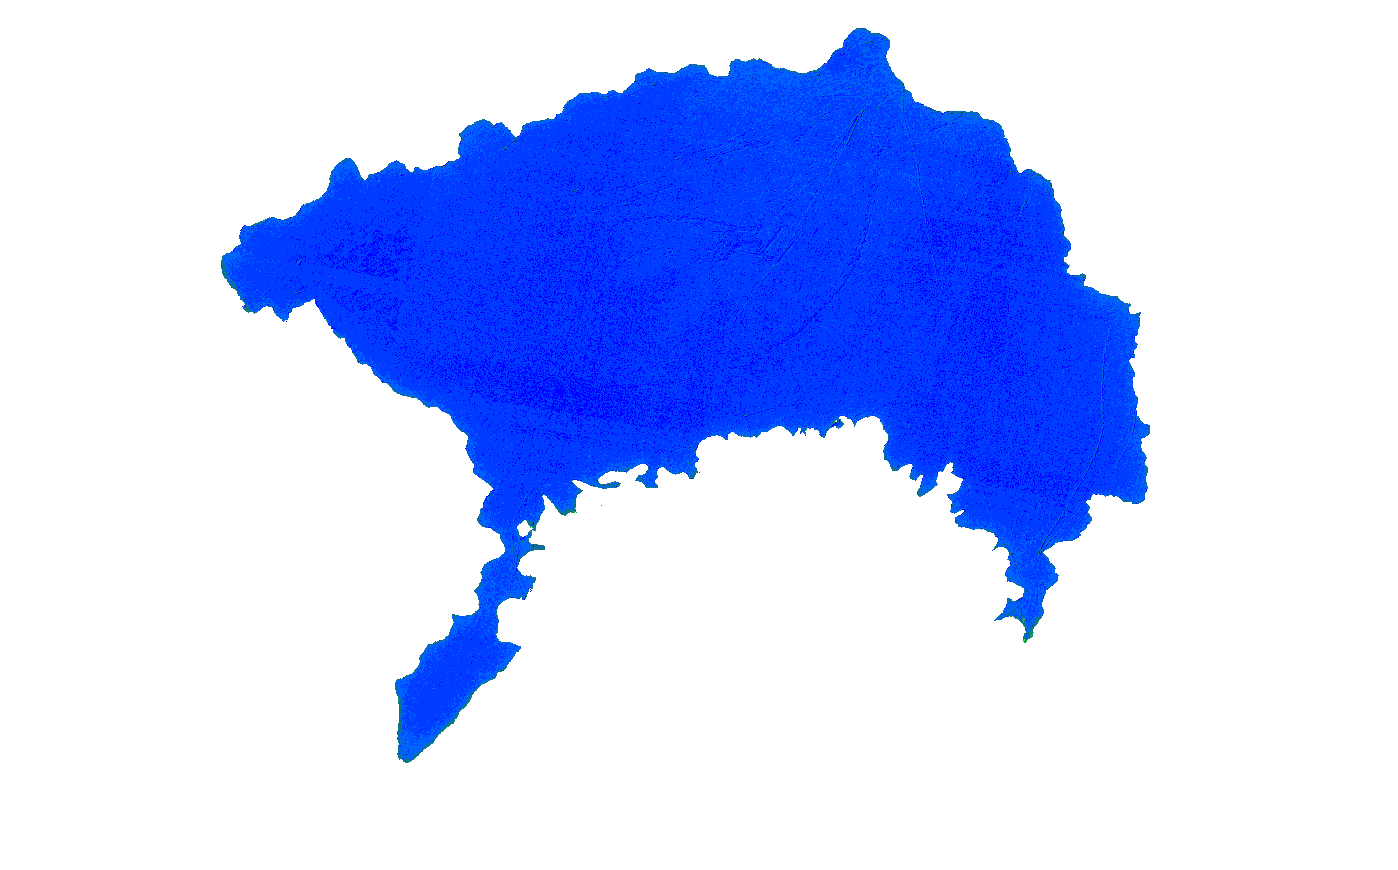
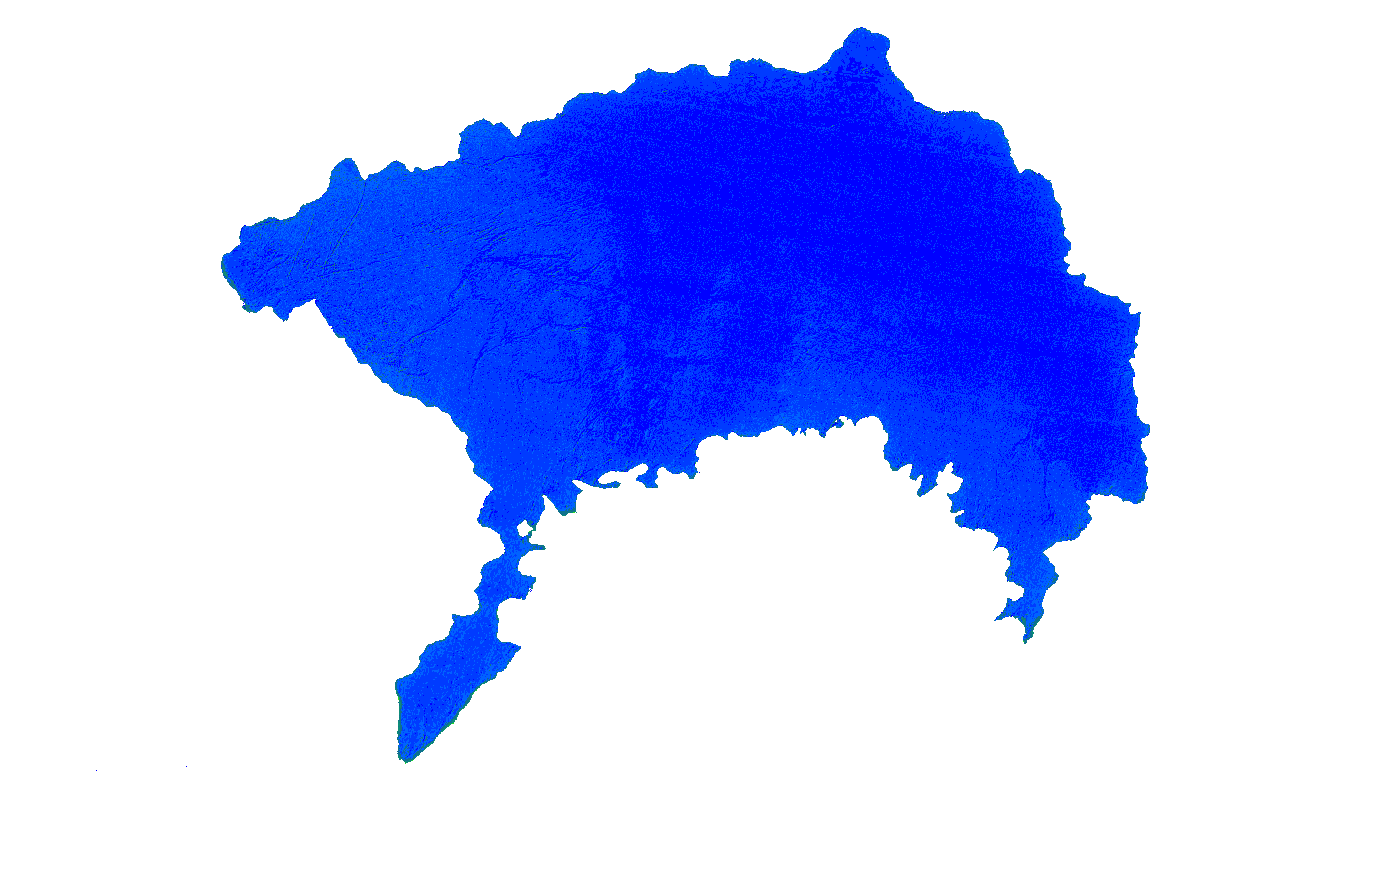
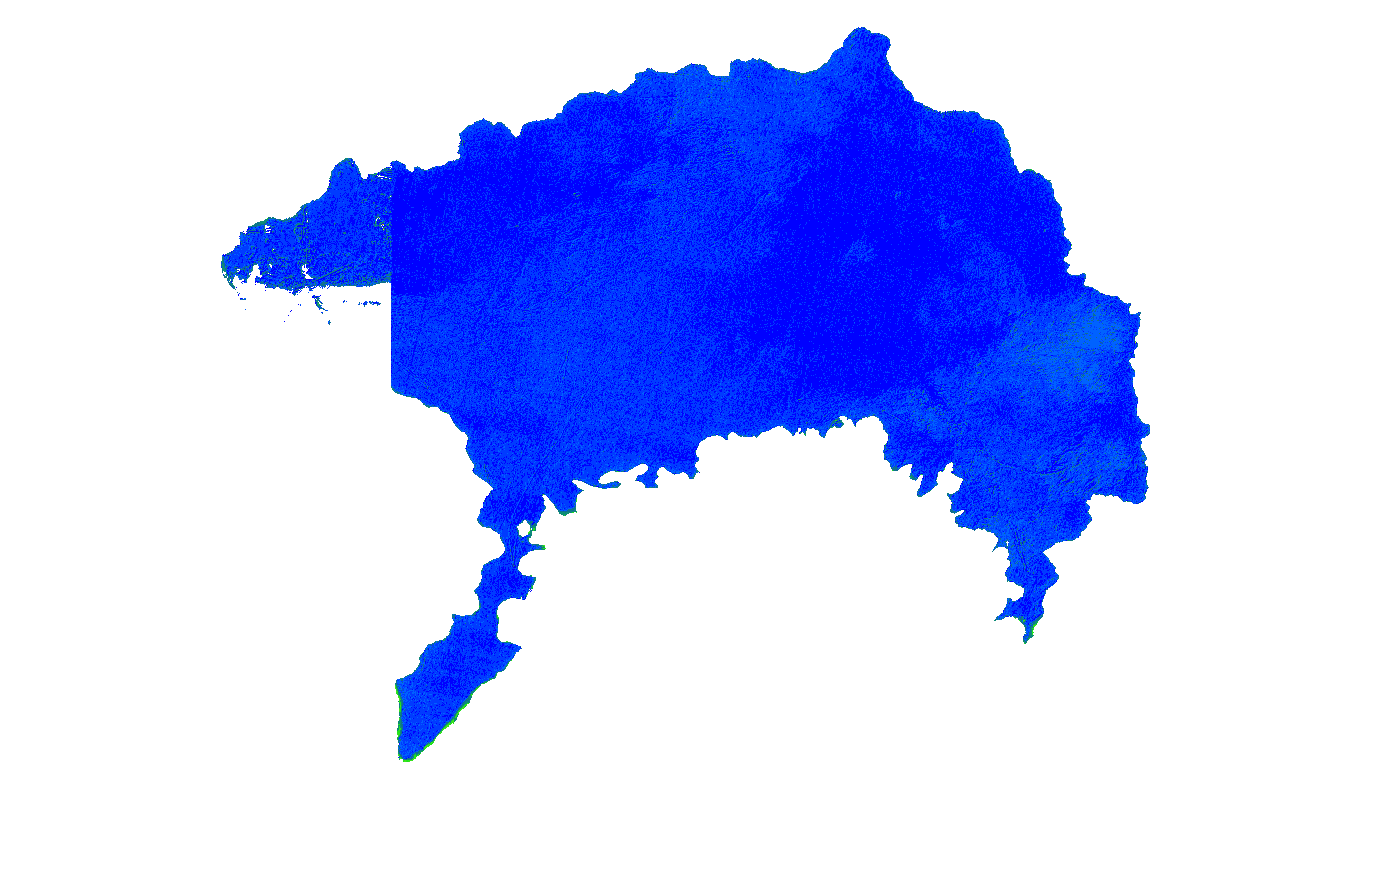
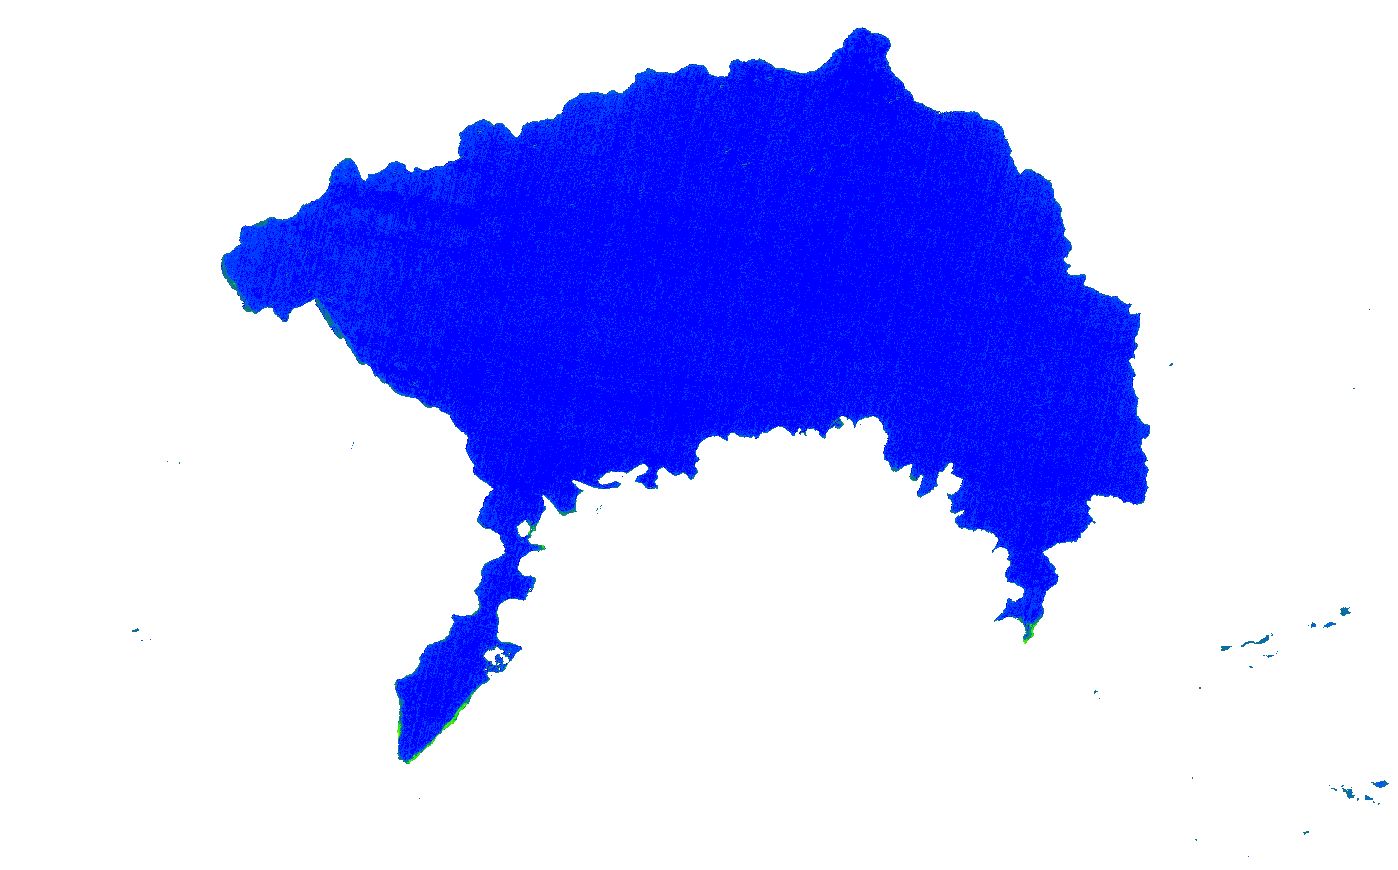
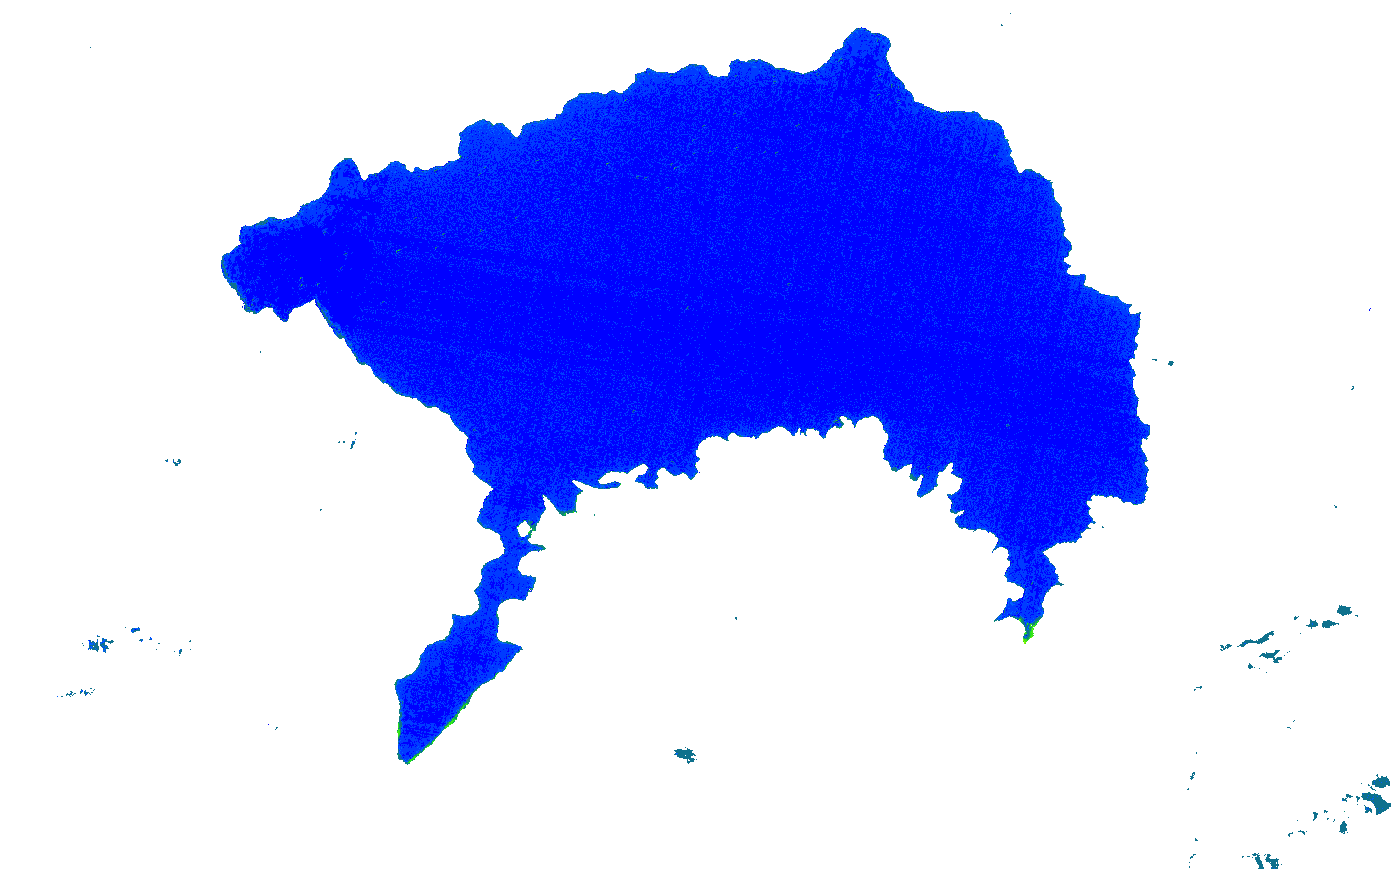
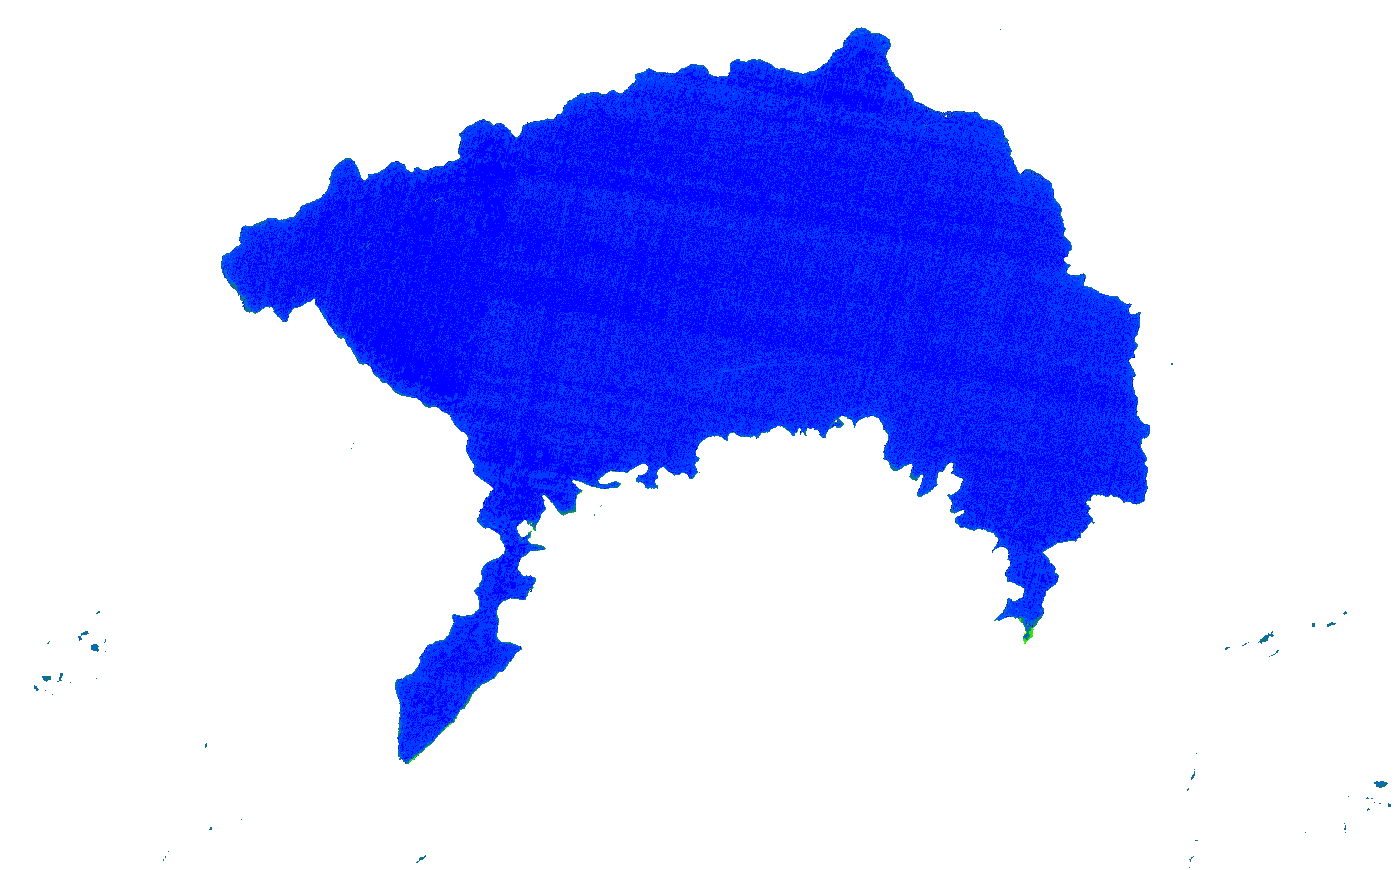
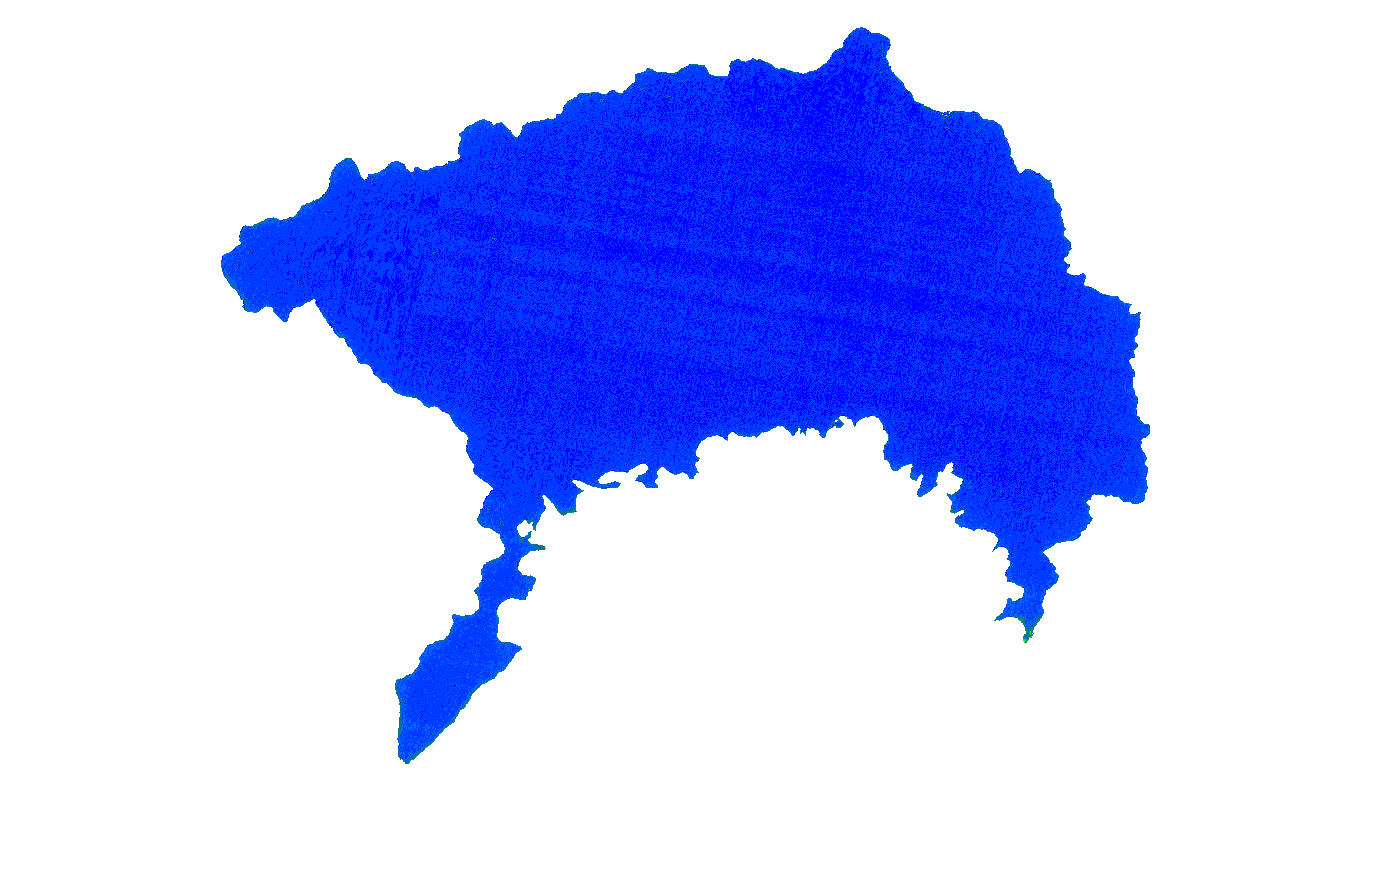
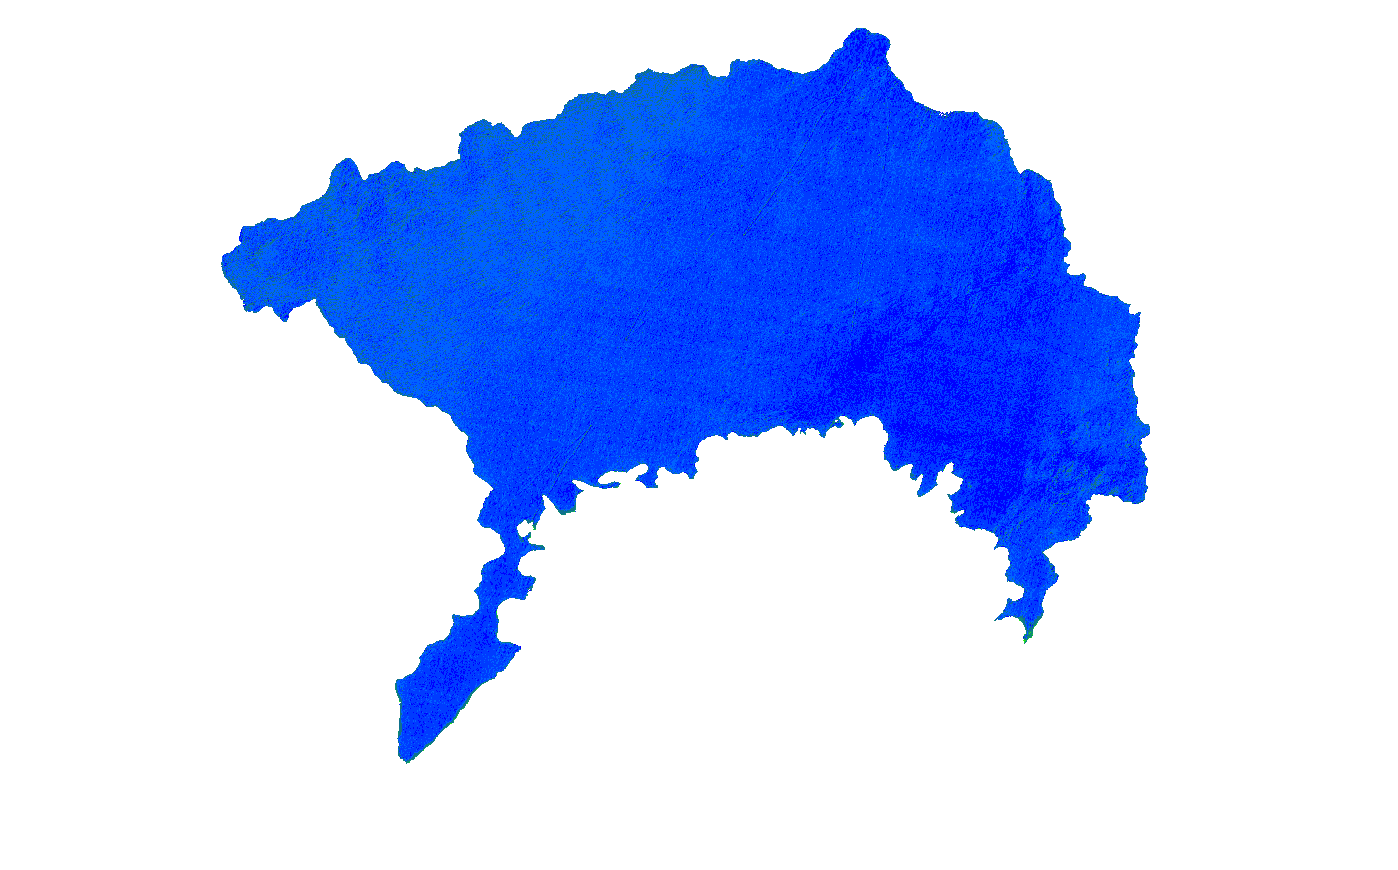
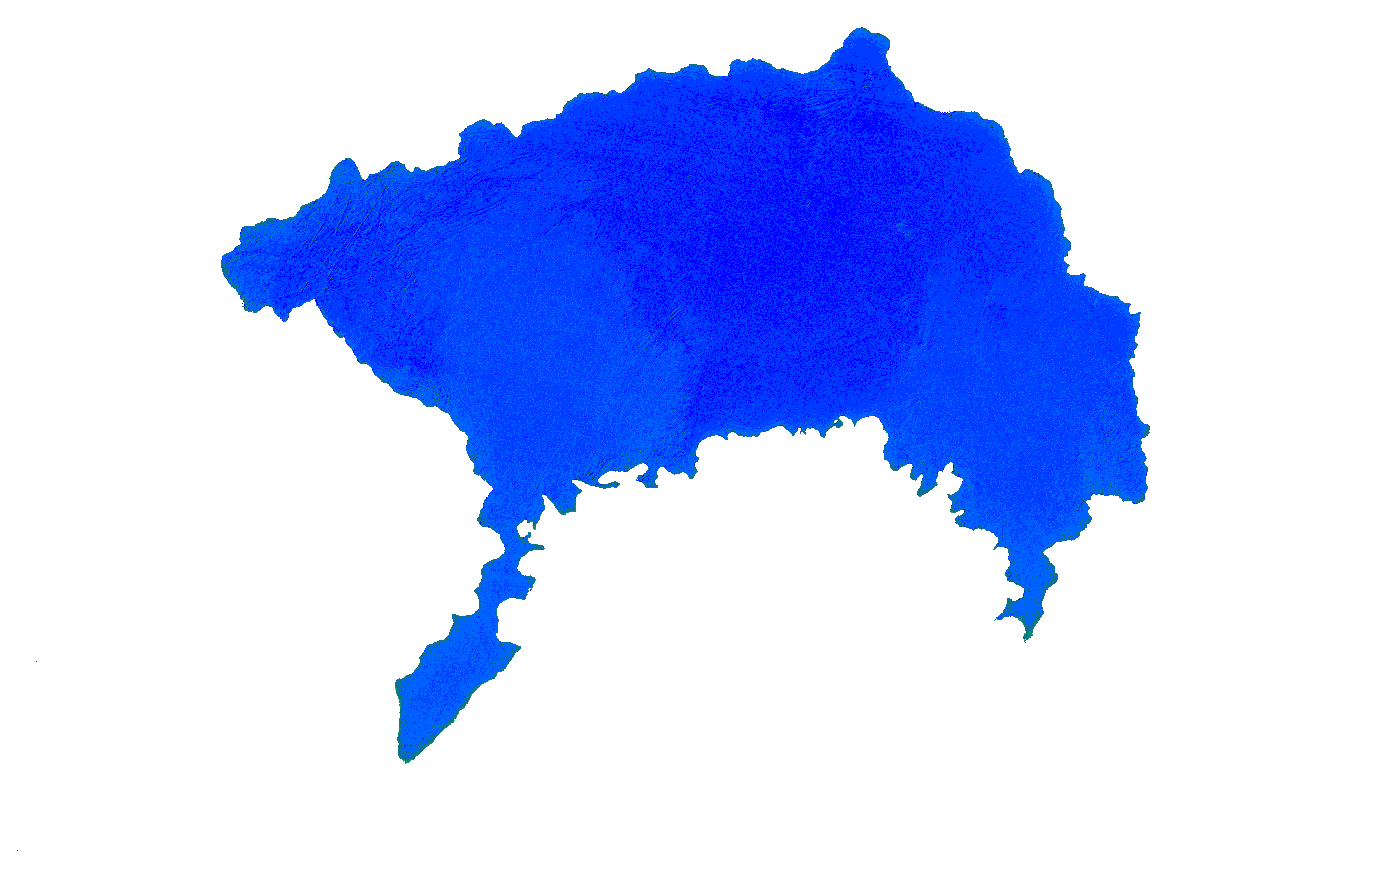
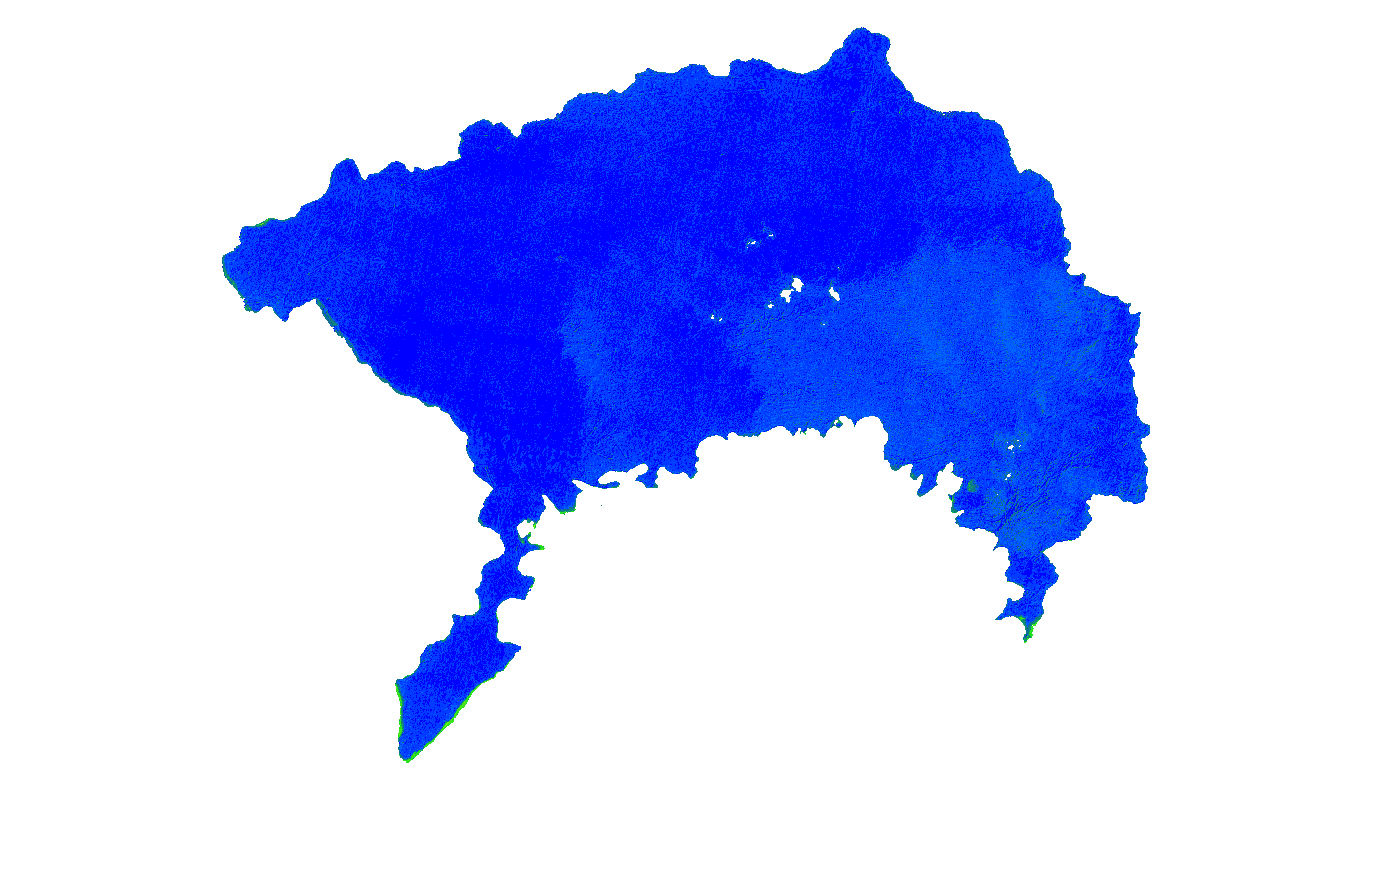

In [2]:
def mapa_interactivo(lago, opacidad=0.8):
    fechas = [f for f in config.FECHAS[lago] if config.ruta_tif(lago, f).exists()]
    _, meta = datos.indices_escena(lago, fechas[0])

    mapa = folium.Map(location=graficos.centro(meta), zoom_start=12, tiles=None)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery", name="Satélite", control=True,
    ).add_to(mapa)
    folium.TileLayer("OpenStreetMap", name="Mapa", control=True).add_to(mapa)

    for i, fecha in enumerate(fechas):
        capas, meta_i = datos.indices_escena(lago, fecha)
        chl_geo, limites = graficos.reproyectar_wgs84(capas["chl_agua"], meta_i)
        media = np.nanmean(chl_geo)
        folium.raster_layers.ImageOverlay(
            image=graficos.rgba_chl(chl_geo),
            bounds=limites,
            opacity=opacidad,
            name=f"{fecha}  (media {media:.1f} µg/L)",
            show=(i == 0),
        ).add_to(mapa)

    # Leyenda con los tramos con sentido ecológico de la escala oficial.
    leyenda = cm.StepColormap(
        colors=["#0000ff", "#0062ff", "#0e8d78", "#1ee21c", "#86f700",
                "#cded00", "#fbd203", "#f5a409", "#ef760f", "#e94815"],
        index=[0, 2.5, 5, 7, 14, 24, 38, 50, 100, 250, 500],
        vmin=0, vmax=500,
        caption=f"Clorofila-a (µg/L) — {config.NOMBRE_LARGO[lago]}",
    )
    leyenda.add_to(mapa)

    Fullscreen().add_to(mapa)
    folium.LayerControl(collapsed=False).add_to(mapa)

    salida = config.FIGURAS / f"mapa_{lago}.html"
    mapa.save(salida)
    print(f"Guardado en {salida.relative_to(config.BASE)}")
    return mapa

mapa_interactivo("Atitlan")

Guardado en data/figuras/mapa_Amatitlan.html



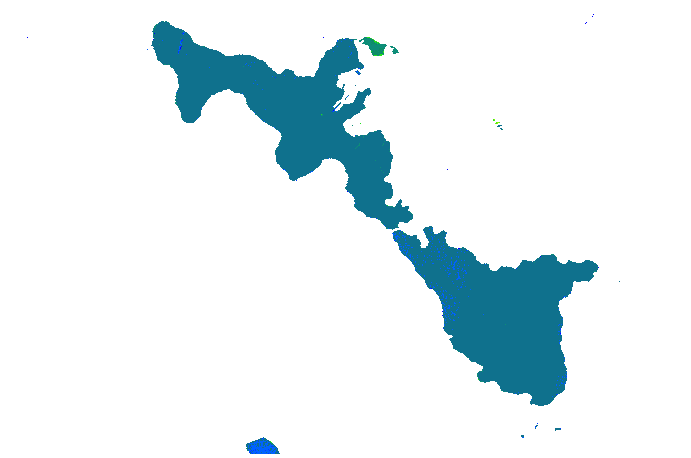
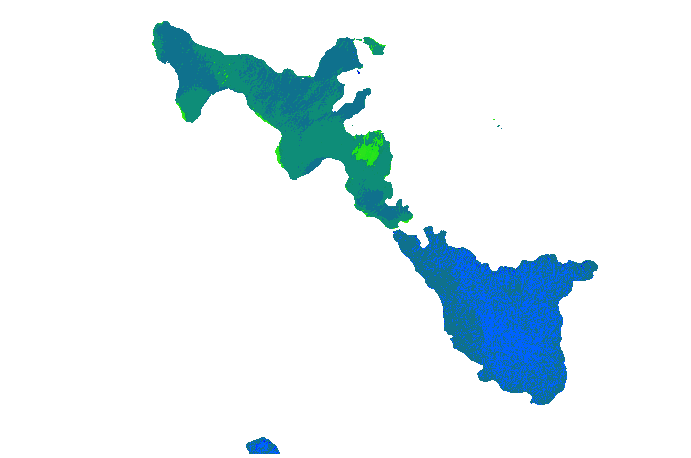
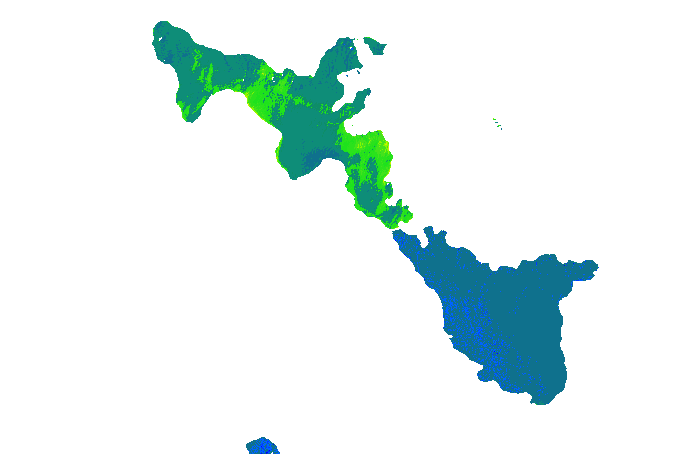
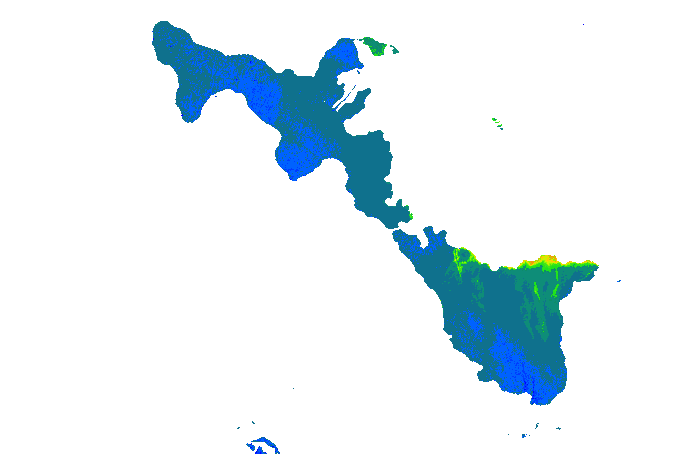
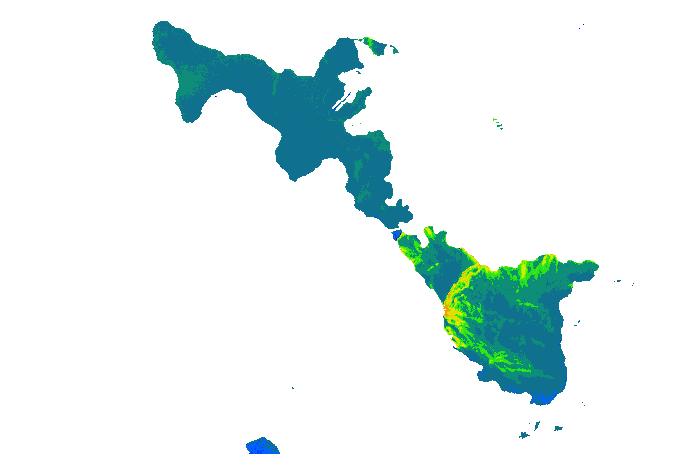
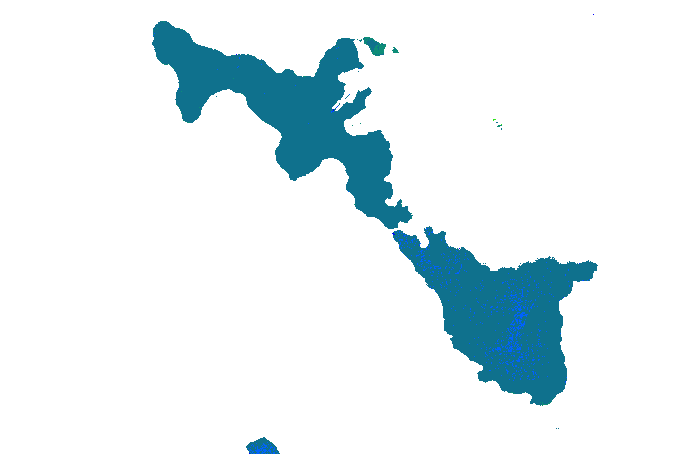
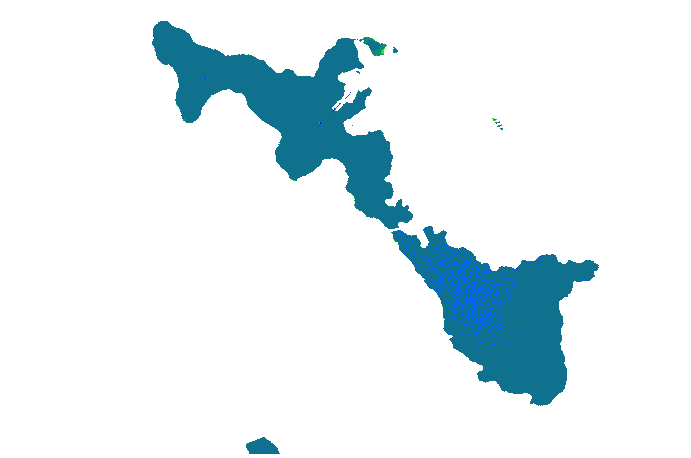
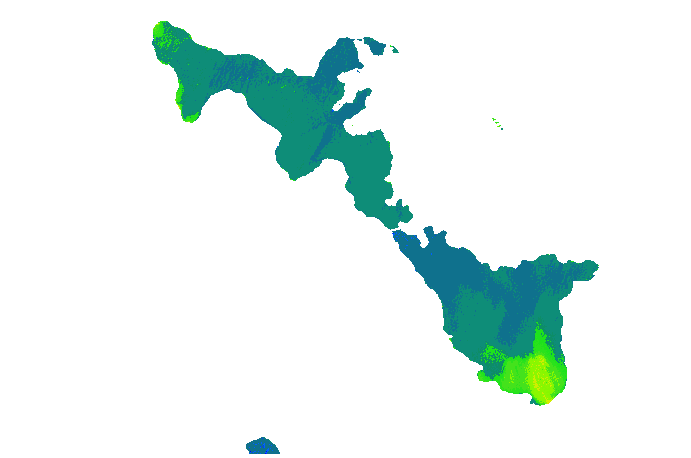
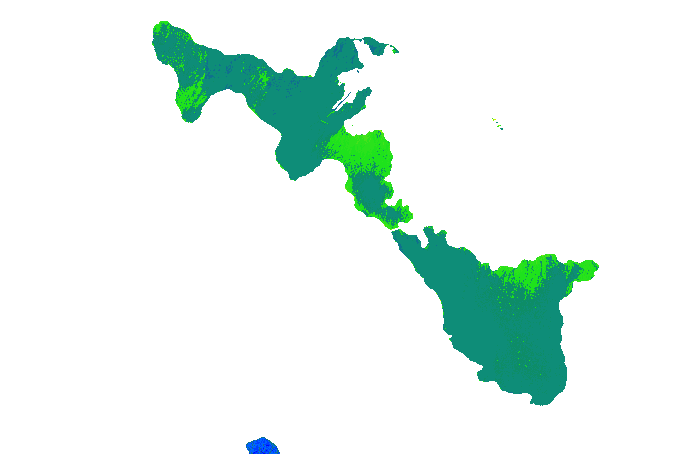
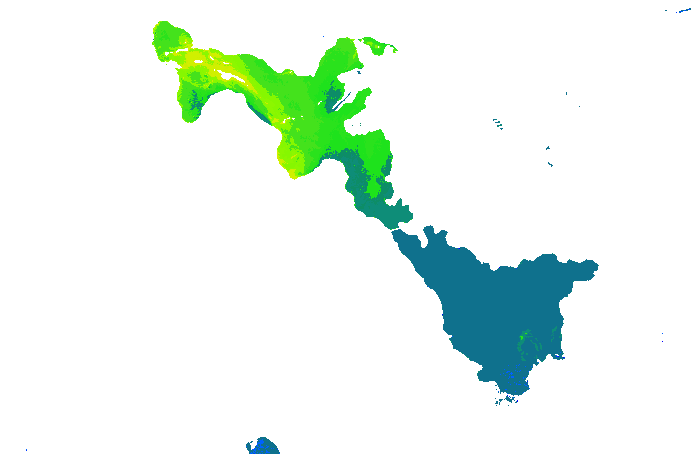
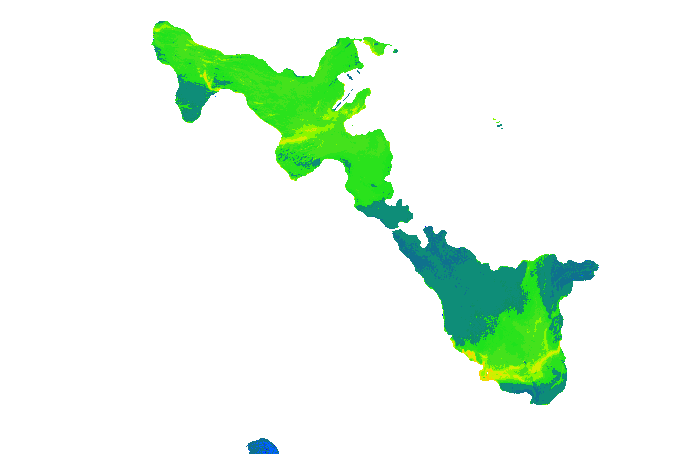

In [3]:
mapa_interactivo("Amatitlan")

## 5.2 Mapas comparativos entre fechas

### La fecha más limpia contra la más cargada

Para cada lago tomamos la escena con el promedio más bajo y la del promedio más alto del
período, y las ponemos lado a lado con su mapa de diferencia.

/var/folders/wg/qbpyvh5n65jd_4mhvvjvclcw0000gn/T/ipykernel_34875/894785816.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


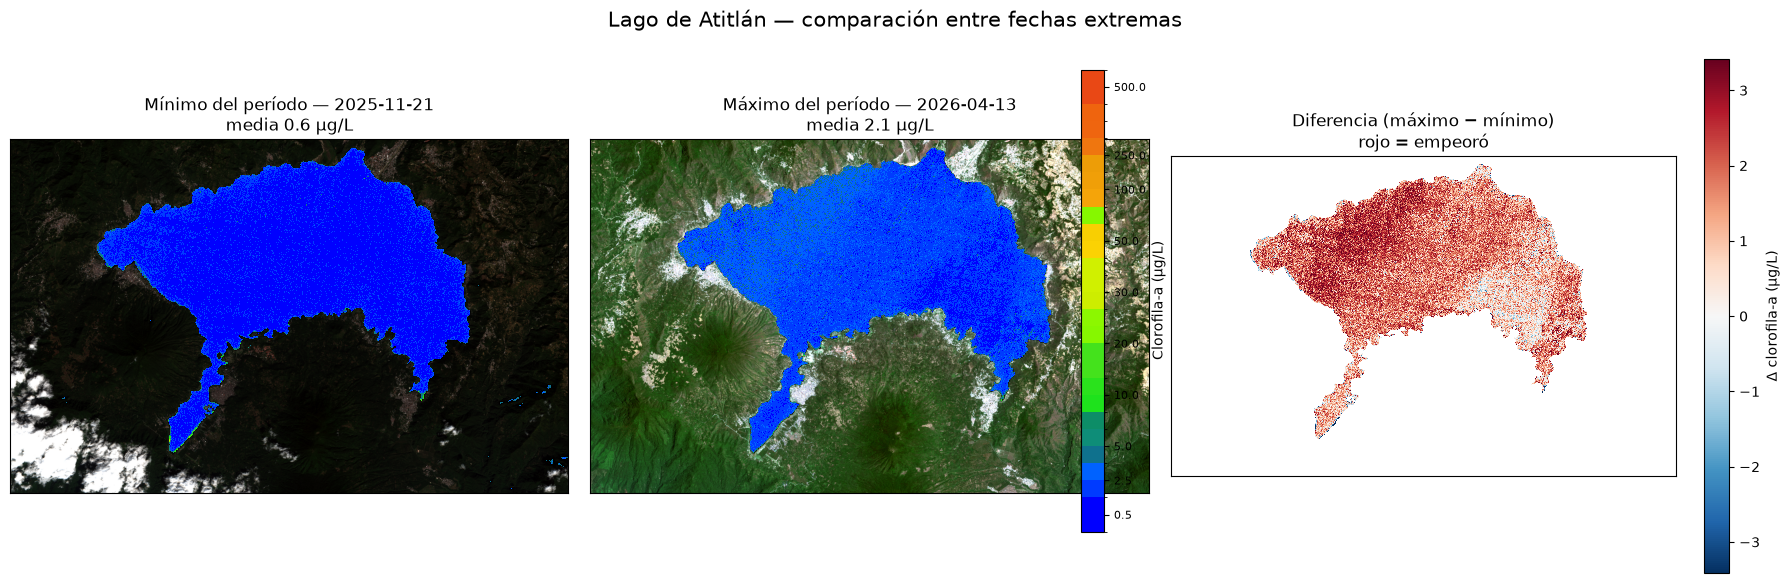

Cambio medio     : +1.6 µg/L
Superficie que empeoró: 91.1%


In [4]:
def comparar_extremos(lago):
    sub = resumen[resumen["lago"] == lago].dropna(subset=["chl_media"])
    f_min = sub.loc[sub["chl_media"].idxmin()]
    f_max = sub.loc[sub["chl_media"].idxmax()]
    fecha_min = f_min["fecha"].strftime("%Y-%m-%d")
    fecha_max = f_max["fecha"].strftime("%Y-%m-%d")

    capas_min, _ = datos.indices_escena(lago, fecha_min)
    capas_max, _ = datos.indices_escena(lago, fecha_max)

    fig, ejes = plt.subplots(1, 3, figsize=(18, 6))

    graficos.dibujar_mapa_chl(
        ejes[0], capas_min,
        f"Mínimo del período — {fecha_min}\nmedia {f_min['chl_media']:.1f} µg/L")
    graficos.dibujar_mapa_chl(
        ejes[1], capas_max,
        f"Máximo del período — {fecha_max}\nmedia {f_max['chl_media']:.1f} µg/L")
    graficos.barra_color_chl(fig, [ejes[0], ejes[1]])

    diferencia = capas_max["chl_agua"] - capas_min["chl_agua"]
    tope = np.nanpercentile(np.abs(diferencia), 98)
    im = ejes[2].imshow(np.ma.masked_invalid(diferencia), cmap="RdBu_r",
                        vmin=-tope, vmax=tope, interpolation="nearest")
    ejes[2].set_title(f"Diferencia (máximo − mínimo)\nrojo = empeoró")
    ejes[2].set_xticks([]); ejes[2].set_yticks([])
    plt.colorbar(im, ax=ejes[2], fraction=0.046, label="Δ clorofila-a (µg/L)")

    fig.suptitle(f"{config.NOMBRE_LARGO[lago]} — comparación entre fechas extremas",
                 fontsize=15)
    fig.tight_layout()
    plt.show()

    validos = np.isfinite(diferencia)
    print(f"Cambio medio     : {np.nanmean(diferencia):+.1f} µg/L")
    print(f"Superficie que empeoró: {100 * np.nansum(diferencia[validos] > 0) / validos.sum():.1f}%")

comparar_extremos("Atitlan")

/var/folders/wg/qbpyvh5n65jd_4mhvvjvclcw0000gn/T/ipykernel_34875/894785816.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


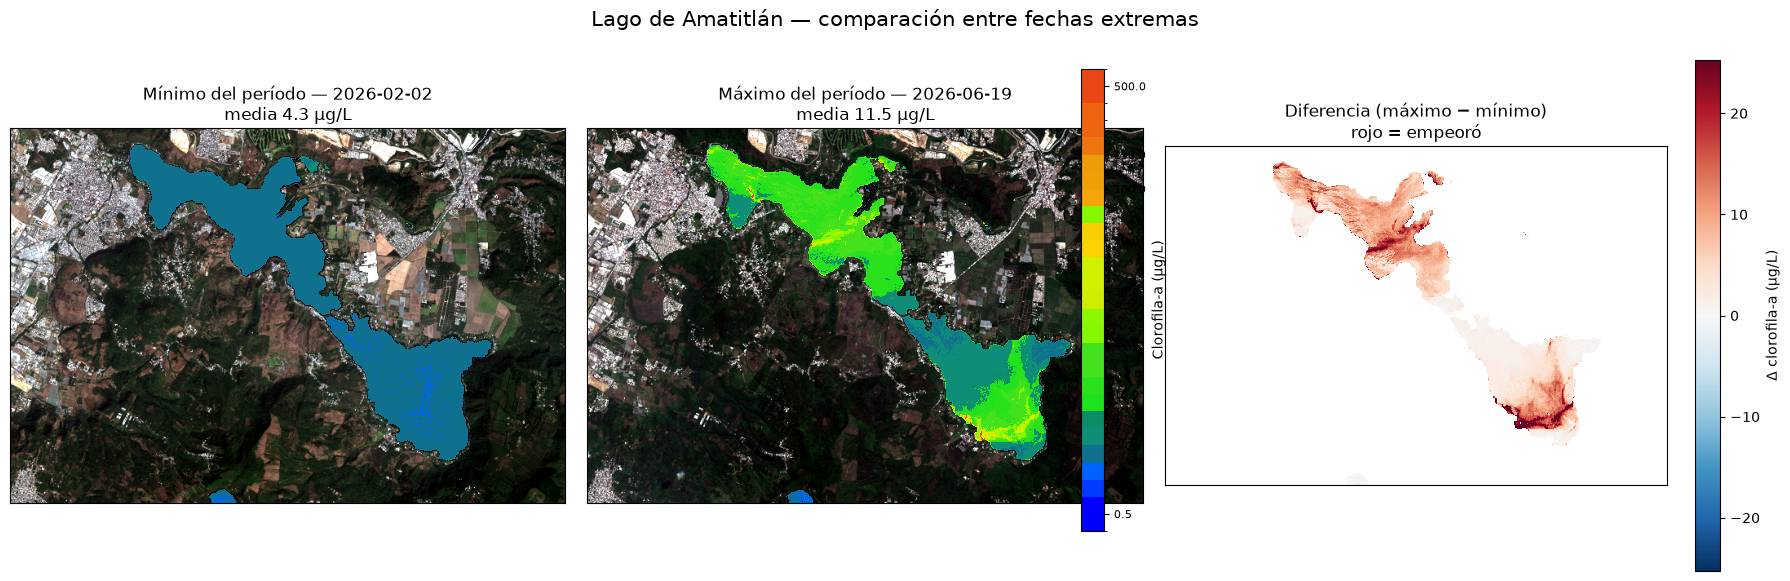

Cambio medio     : +7.2 µg/L
Superficie que empeoró: 99.3%


In [5]:
comparar_extremos("Amatitlan")

### Evolución fecha a fecha

La secuencia completa de diferencias respecto a la escena anterior deja ver si el lago se está
cargando o descargando de forma gradual, o si los cambios son bruscos.

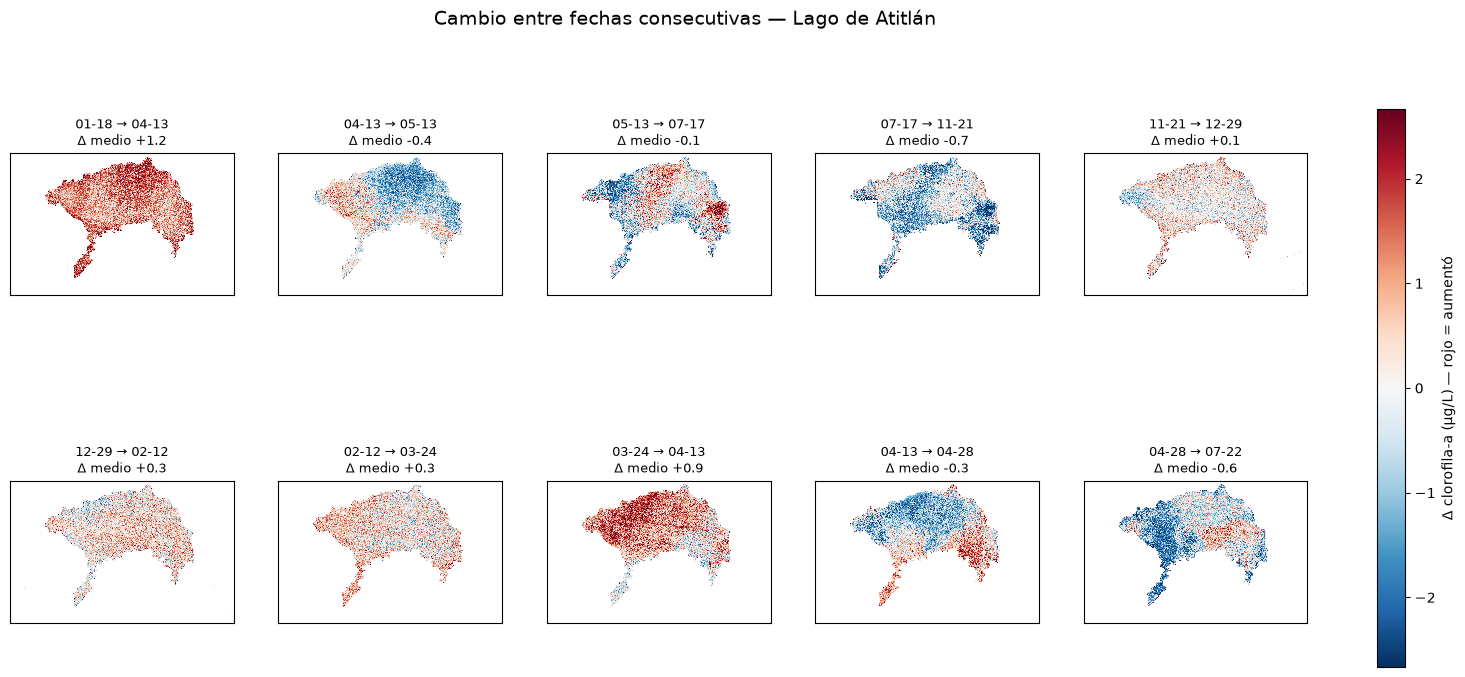

In [6]:
def secuencia_diferencias(lago, columnas=5):
    pila, fechas, _ = datos.pila_chl(lago)
    n = len(fechas) - 1
    filas = int(np.ceil(n / columnas))
    fig, ejes = plt.subplots(filas, columnas, figsize=(3.6 * columnas, 3.9 * filas))
    ejes = np.atleast_1d(ejes).ravel()

    diferencias = [pila[i + 1] - pila[i] for i in range(n)]
    tope = np.nanpercentile(np.abs(np.concatenate([d.ravel() for d in diferencias])), 98)

    for eje, i in zip(ejes, range(n)):
        im = eje.imshow(np.ma.masked_invalid(diferencias[i]), cmap="RdBu_r",
                        vmin=-tope, vmax=tope, interpolation="nearest")
        cambio = np.nanmean(diferencias[i])
        eje.set_title(f"{fechas[i][5:]} → {fechas[i+1][5:]}\nΔ medio {cambio:+.1f}",
                      fontsize=9)
        eje.set_xticks([]); eje.set_yticks([])

    for eje in ejes[n:]:
        eje.axis("off")

    fig.colorbar(im, ax=list(ejes[:n]), fraction=0.02,
                 label="Δ clorofila-a (µg/L) — rojo = aumentó")
    fig.suptitle(f"Cambio entre fechas consecutivas — {config.NOMBRE_LARGO[lago]}",
                 fontsize=14)
    plt.show()

secuencia_diferencias("Atitlan")

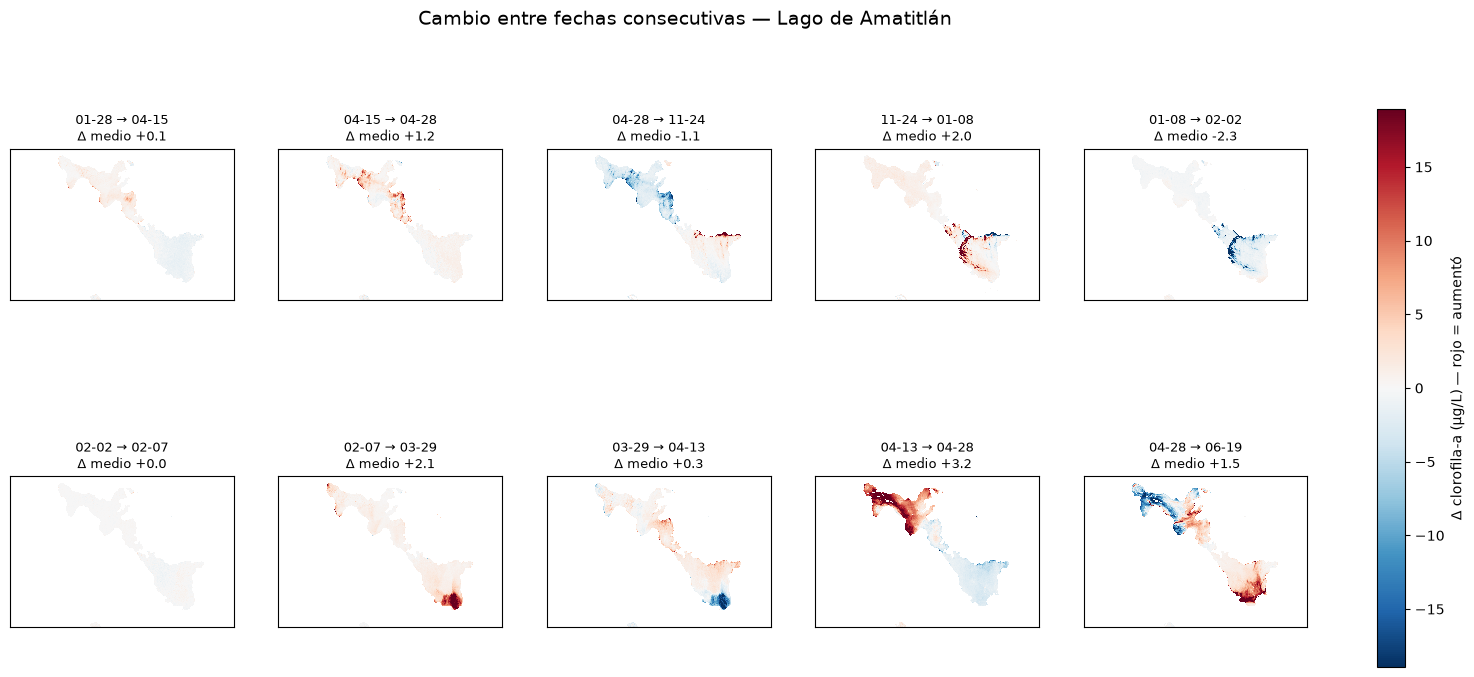

In [7]:
secuencia_diferencias("Amatitlan")

## 5.3 Zonas persistentes de acumulación

La pregunta clave para gestión ambiental no es solo *cuánta* cianobacteria hay, sino *si
siempre se junta en el mismo lugar*. Una zona que aparece cargada en casi todas las fechas
apunta a una causa fija —una desembocadura, una descarga, una zona de poca circulación— y no a
un evento pasajero.

Calculamos, para cada píxel de agua, en qué **porcentaje de las fechas observadas** superó el
umbral de alerta. También calculamos el promedio de todo el período píxel por píxel.

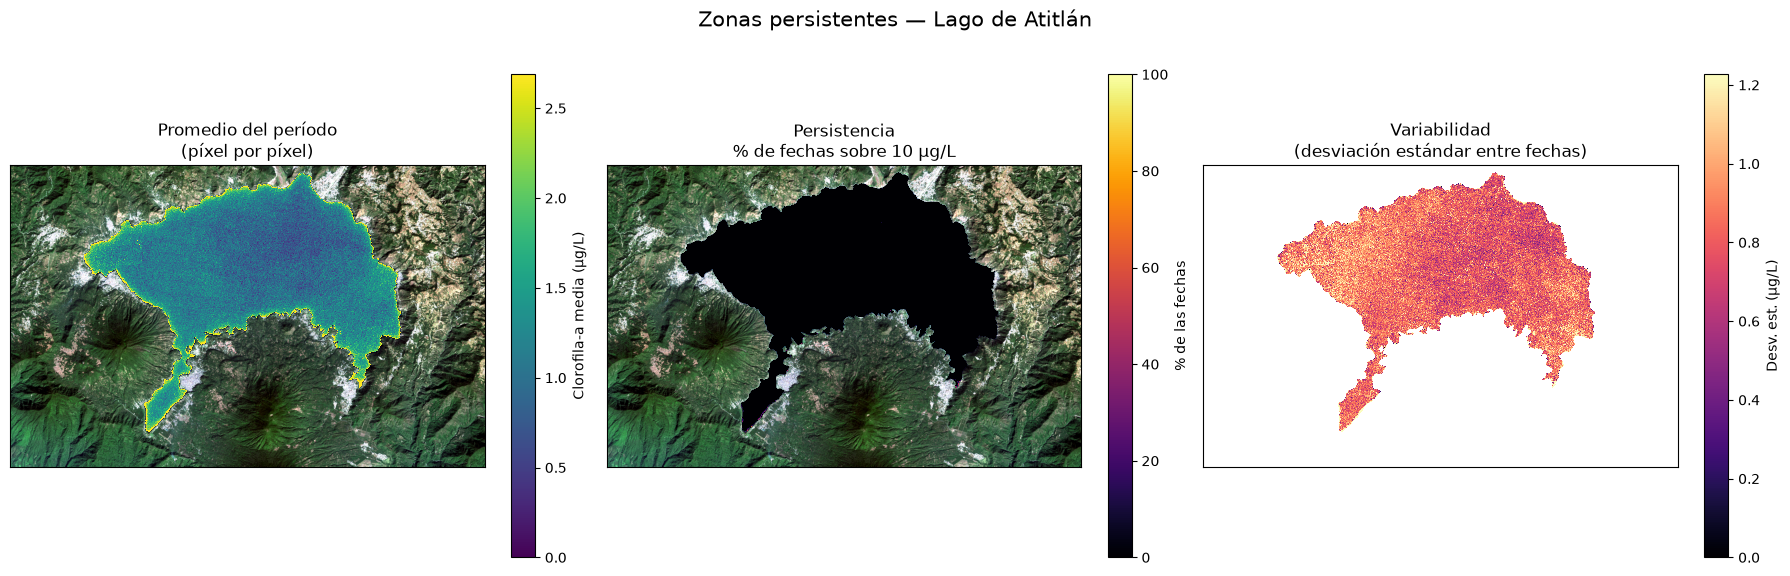

Píxeles de agua analizados     : 305,600
Superficie que supera el umbral en ≥25% de las fechas:   0.0%
Superficie que supera el umbral en ≥50% de las fechas:   0.0%
Superficie que supera el umbral en ≥75% de las fechas:   0.0%
Persistencia máxima observada  : 78% de las fechas


In [8]:
def mapa_persistencia(lago):
    pila, fechas, meta = datos.pila_chl(lago)

    observaciones = np.sum(np.isfinite(pila), axis=0)
    excesos = np.sum(pila > ix.UMBRAL_ALTO_CHL, axis=0)
    # Solo píxeles con al menos la mitad de las fechas observadas, para no
    # sacar conclusiones de un píxel visto una sola vez.
    confiable = observaciones >= max(2, len(fechas) // 2)

    persistencia = np.where(confiable, 100 * excesos / np.maximum(observaciones, 1), np.nan)
    # Los píxeles sin ninguna observación dan un aviso de "media de rebanada
    # vacía" que aquí no aporta nada: ya quedan excluidos por `confiable`.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        promedio = np.where(confiable, np.nanmean(pila, axis=0), np.nan)

    fig, ejes = plt.subplots(1, 3, figsize=(18, 6))

    capas, _ = datos.indices_escena(lago, fechas[0])
    ejes[0].imshow(graficos.color_verdadero_realzado(capas))
    im0 = ejes[0].imshow(np.ma.masked_invalid(promedio), cmap="viridis",
                         vmin=0, vmax=np.nanpercentile(promedio, 98),
                         interpolation="nearest")
    ejes[0].set_title("Promedio del período\n(píxel por píxel)")
    plt.colorbar(im0, ax=ejes[0], fraction=0.046, label="Clorofila-a media (µg/L)")

    ejes[1].imshow(graficos.color_verdadero_realzado(capas))
    im1 = ejes[1].imshow(np.ma.masked_invalid(persistencia), cmap="inferno",
                         vmin=0, vmax=100, interpolation="nearest")
    ejes[1].set_title(f"Persistencia\n% de fechas sobre {ix.UMBRAL_ALTO_CHL:.0f} µg/L")
    plt.colorbar(im1, ax=ejes[1], fraction=0.046, label="% de las fechas")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        variabilidad = np.where(confiable, np.nanstd(pila, axis=0), np.nan)
    im2 = ejes[2].imshow(np.ma.masked_invalid(variabilidad), cmap="magma",
                         vmin=0, vmax=np.nanpercentile(variabilidad, 98),
                         interpolation="nearest")
    ejes[2].set_title("Variabilidad\n(desviación estándar entre fechas)")
    plt.colorbar(im2, ax=ejes[2], fraction=0.046, label="Desv. est. (µg/L)")

    for eje in ejes:
        eje.set_xticks([]); eje.set_yticks([])

    fig.suptitle(f"Zonas persistentes — {config.NOMBRE_LARGO[lago]}", fontsize=15)
    fig.tight_layout()
    plt.show()

    con_dato = np.isfinite(persistencia)
    print(f"Píxeles de agua analizados     : {con_dato.sum():,}")
    for corte in (25, 50, 75):
        frac = 100 * np.nansum(persistencia >= corte) / con_dato.sum()
        print(f"Superficie que supera el umbral en ≥{corte}% de las fechas: {frac:5.1f}%")
    print(f"Persistencia máxima observada  : {np.nanmax(persistencia):.0f}% de las fechas")

    return persistencia, promedio, meta

persistencia_atitlan, promedio_atitlan, meta_atitlan = mapa_persistencia("Atitlan")

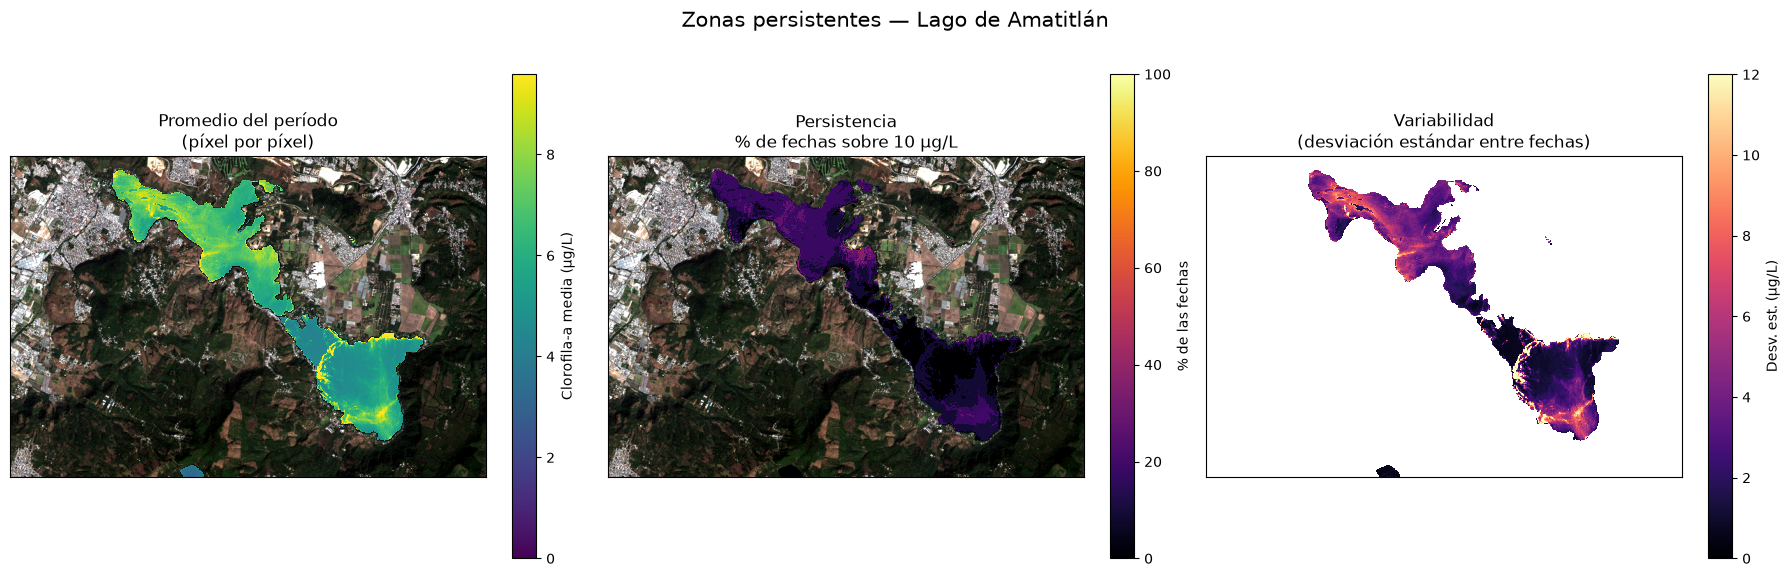

Píxeles de agua analizados     : 36,804
Superficie que supera el umbral en ≥25% de las fechas:   5.8%
Superficie que supera el umbral en ≥50% de las fechas:   0.1%
Superficie que supera el umbral en ≥75% de las fechas:   0.0%
Persistencia máxima observada  : 83% de las fechas


In [9]:
persistencia_amatitlan, promedio_amatitlan, meta_amatitlan = mapa_persistencia("Amatitlan")

### Dónde están exactamente los focos

Localizamos los puntos más cargados en coordenadas geográficas, para poder nombrarlos y
relacionarlos con lo que hay en la orilla.

In [10]:
from rasterio.transform import xy
from rasterio.warp import transform as transformar_coords

# Devuelve los n puntos más cargados del período, separados entre sí para no
# reportar varias veces el mismo foco.
def focos(lago, promedio, meta, n=6, separacion=25):
    trabajo = promedio.copy()
    puntos = []
    for _ in range(n):
        if not np.isfinite(trabajo).any():
            break
        idx = np.nanargmax(trabajo)
        fila, columna = np.unravel_index(idx, trabajo.shape)
        valor = trabajo[fila, columna]

        x, y = xy(meta["transform"], int(fila), int(columna))
        lon, lat = transformar_coords(meta["crs"], graficos.WGS84, [x], [y])
        puntos.append({"lat": round(lat[0], 5), "lon": round(lon[0], 5),
                       "chl_media_periodo": round(float(valor), 1)})

        # Se apaga un entorno para no reportar seis veces el mismo foco.
        f0, f1 = max(0, fila - separacion), fila + separacion
        c0, c1 = max(0, columna - separacion), columna + separacion
        trabajo[f0:f1, c0:c1] = np.nan

    tabla = pd.DataFrame(puntos)
    print(f"\n{config.NOMBRE_LARGO[lago]} — focos de mayor carga promedio")
    print(tabla.to_string(index=False))
    return tabla

focos_at = focos("Atitlan", promedio_atitlan, meta_atitlan)
focos_am = focos("Amatitlan", promedio_amatitlan, meta_amatitlan)


Lago de Atitlán — focos de mayor carga promedio
     lat       lon  chl_media_periodo
14.63456 -91.13870               14.6
14.71175 -91.25709               13.2
14.61810 -91.25430               11.3
14.61535 -91.24894               10.8
14.64449 -91.22959               10.7
14.65852 -91.22186               10.4

Lago de Amatitlán — focos de mayor carga promedio
     lat       lon  chl_media_periodo
14.44793 -90.53756               20.6
14.44673 -90.54332               19.2
14.47334 -90.54840               17.1
14.47054 -90.57477               16.5
14.43802 -90.55732               16.1
14.44485 -90.55409               15.5


Guardado en data/figuras/persistencia_Amatitlan.html



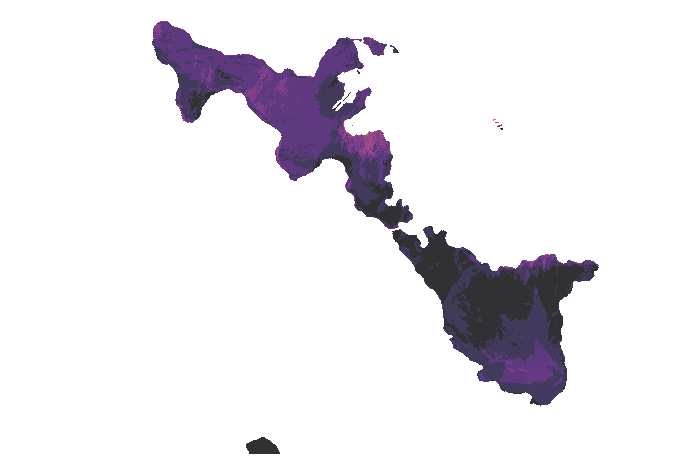

In [11]:
def mapa_focos(lago, persistencia, meta, tabla_focos):
    persistencia_geo, limites = graficos.reproyectar_wgs84(persistencia, meta)

    mapa = folium.Map(location=graficos.centro(meta), zoom_start=12, tiles=None)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery", name="Satélite",
    ).add_to(mapa)

    from matplotlib import colormaps
    from matplotlib.colors import Normalize

    paleta = colormaps["inferno"]
    rgba = (paleta(Normalize(0, 100)(np.ma.masked_invalid(persistencia_geo))) * 255)
    rgba = rgba.astype(np.uint8)
    rgba[..., 3] = np.where(np.isfinite(persistencia_geo), 205, 0)

    escala = cm.LinearColormap(
        colors=["#000004", "#781c6d", "#ed6925", "#fcffa4"],
        vmin=0, vmax=100,
        caption=f"% de fechas sobre {ix.UMBRAL_ALTO_CHL:.0f} µg/L",
    )

    folium.raster_layers.ImageOverlay(
        image=rgba, bounds=limites, opacity=0.85, name="Persistencia",
    ).add_to(mapa)

    for _, punto in tabla_focos.iterrows():
        folium.CircleMarker(
            location=[punto["lat"], punto["lon"]], radius=7,
            color="#ffffff", weight=2, fill=True, fill_color="#d7191c", fill_opacity=0.9,
            popup=f"{punto['chl_media_periodo']} µg/L promedio del período",
            tooltip=f"Foco: {punto['chl_media_periodo']} µg/L",
        ).add_to(mapa)

    escala.add_to(mapa)
    Fullscreen().add_to(mapa)
    folium.LayerControl(collapsed=False).add_to(mapa)

    salida = config.FIGURAS / f"persistencia_{lago}.html"
    mapa.save(salida)
    print(f"Guardado en {salida.relative_to(config.BASE)}")
    return mapa

mapa_focos("Amatitlan", persistencia_amatitlan, meta_amatitlan, focos_am)

Guardado en data/figuras/persistencia_Atitlan.html



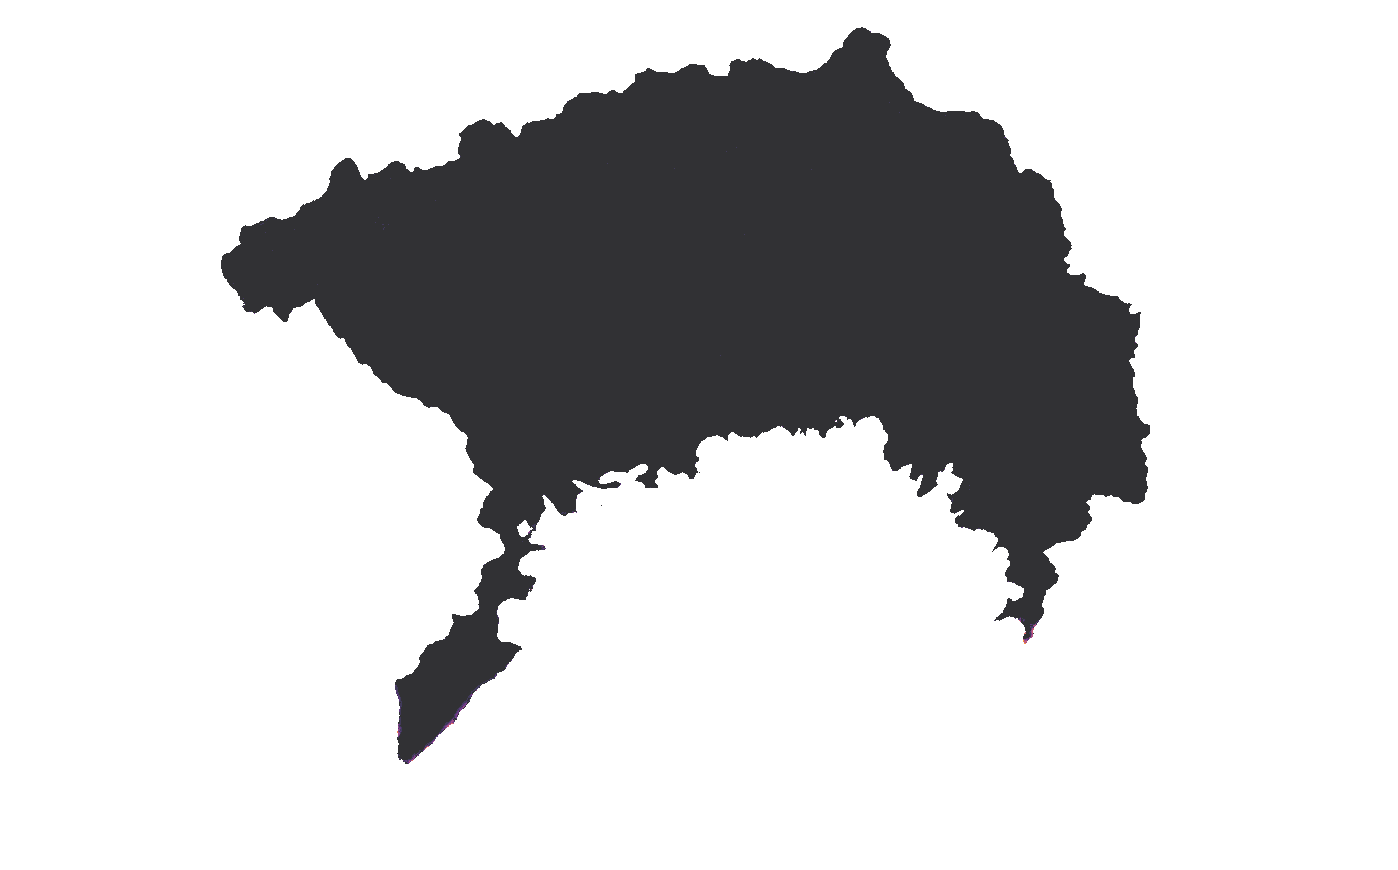

In [12]:
mapa_focos("Atitlan", persistencia_atitlan, meta_atitlan, focos_at)

## 5.3 Interpretación de los patrones espaciales

### Dónde se acumula, en cada lago

Los focos que localizamos no están repartidos al azar. Convertidos a coordenadas y cruzados con
los poblados de la orilla:

**Amatitlán** — los seis focos más cargados del período están todos en la **mitad oriental** del
lago, entre 2.8 y 6.6 km de San Miguel Petapa, con promedios de 15.5 a 20.6 µg/L. Ahí desemboca
el **río Villalobos**, que drena buena parte del área metropolitana de la ciudad de Guatemala y
llega cargado de aguas residuales. El patrón es exactamente el que se esperaría de una fuente
puntual: máximo cerca de la desembocadura y decreciente hacia el resto del cuerpo de agua.

**Atitlán** — los focos son mucho más débiles (10.4 a 14.6 µg/L de promedio) y se concentran en
dos zonas: la **bahía de Santiago**, entre 0.6 y 3.5 km de Santiago Atitlán, y el sector frente a
**San Lucas Tolimán**. Ambas son bahías cerradas, con poblados en la orilla y ríos estacionales
que bajan de la cuenca. Un tercer foco aparece cerca de Santa Cruz La Laguna.

En los dos casos los valores altos aparecen **pegados a la orilla y frente a poblaciones o
desembocaduras**, nunca en el centro del lago. Eso es coherente con un origen terrestre del
nutriente y no con un fenómeno de masa de agua.

### Qué tan persistentes son

La distinción entre "se puso mal una vez" y "está mal siempre" cambia por completo la lectura
para gestión:

| | Atitlán | Amatitlán |
|---|---|---|
| Superficie que **nunca** supera 10 µg/L | 99.8 % (122.0 km²) | 28.5 % (4.2 km²) |
| Afectación **ocasional** (1–25 % de las fechas) | 0.2 % | 65.8 % (9.7 km²) |
| Afectación **recurrente** (25–50 %) | 0.0 % | 5.6 % (0.8 km²) |
| Persistencia máxima en un píxel | 78 % de las fechas | 83 % de las fechas |

En Atitlán la afectación es puntual y prácticamente inexistente: el 99.8 % del lago no cruza el
umbral en ninguna fecha. En Amatitlán se invierte: solo un 28.5 % del lago se libra, y hay
**0.8 km² que superan el umbral en una de cada cuatro fechas o más**. Esa franja recurrente está
en el sector oriental, frente a la entrada del Villalobos.

Lo interesante es que ningún píxel llega a "crónico" (>75 % de las fechas) en ninguno de los dos
lagos. Ni siquiera la zona más castigada de Amatitlán está permanentemente florecida: la
floración va y viene, pero vuelve siempre al mismo sitio. Para gestión eso es una buena noticia,
porque significa que el sistema todavía responde y que actuar sobre la fuente puntual —el
Villalobos— tendría efecto medible.

### Cómo cambia entre fechas

La comparación entre la fecha más limpia y la más cargada de cada lago muestra que el cambio no
es local sino generalizado: en Atitlán el 91.1 % de la superficie empeoró entre su mínimo y su
máximo (con un cambio medio de +1.6 µg/L), y en Amatitlán el 99.3 % (+7.2 µg/L de media).

Es decir, cuando estos lagos se cargan **no lo hacen por una mancha que crece**, sino por un
ascenso simultáneo de casi todo el espejo de agua, sobre el que se superponen los focos
persistentes. Eso apunta a un forzamiento común —temperatura, estratificación, nivel del
lago— más que a un vertido puntual episódico.